## Importaciones de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import charge_path, first_visualizer, normalize_string_columns, normalize_date_columns, identify_outliers, show_head, show_info, delete_columns, load_clean_data

## Carga de datos

In [2]:
PATH = '../output/global_activity_clients.csv'
df = charge_path(PATH)
show_head(df)

,rental_id,rental_date,return_date,customer_id,film_id,inventory_id,payment_date,amount,rental_duration
0,1,2005-05-24 22:53:30,2005-05-26 22:04:30,130,80,367,2005-05-24 22:53:30,2.99,2
1,2,2005-05-24 22:54:33,2005-05-28 19:40:33,459,333,1525,2005-05-24 22:54:33,2.99,4
2,3,2005-05-24 23:03:39,2005-06-01 22:12:39,408,373,1711,2005-05-24 23:03:39,3.99,8
3,4,2005-05-24 23:04:41,2005-06-03 01:43:41,333,535,2452,2005-05-24 23:04:41,4.99,10
4,5,2005-05-24 23:05:21,2005-06-02 04:33:21,222,450,2079,2005-05-24 23:05:21,6.99,9
5,6,2005-05-24 23:08:07,2005-05-27 01:32:07,549,613,2792,2005-05-24 23:08:07,0.99,3
6,7,2005-05-24 23:11:53,2005-05-29 20:34:53,269,870,3995,2005-05-24 23:11:53,1.99,5
7,8,2005-05-24 23:31:46,2005-05-27 23:33:46,239,510,2346,2005-05-24 23:31:46,4.99,3
8,9,2005-05-25 00:00:40,2005-05-28 00:22:40,126,565,2580,2005-05-25 00:00:40,4.99,3
9,10,2005-05-25 00:02:21,2005-05-31 22:44:21,399,396,1824,2005-05-25 00:02:21,5.99,6


## Exploración rápida del dataset

In [3]:
num_columnas, num_filas, num_duplicados, null_values, df_porcentaje_nulos_columna, df_describe_numeric, df_describe_categorical = first_visualizer(df)

In [4]:
show_head(df)

,rental_id,rental_date,return_date,customer_id,film_id,inventory_id,payment_date,amount,rental_duration
0,1,2005-05-24 22:53:30,2005-05-26 22:04:30,130,80,367,2005-05-24 22:53:30,2.99,2
1,2,2005-05-24 22:54:33,2005-05-28 19:40:33,459,333,1525,2005-05-24 22:54:33,2.99,4
2,3,2005-05-24 23:03:39,2005-06-01 22:12:39,408,373,1711,2005-05-24 23:03:39,3.99,8
3,4,2005-05-24 23:04:41,2005-06-03 01:43:41,333,535,2452,2005-05-24 23:04:41,4.99,10
4,5,2005-05-24 23:05:21,2005-06-02 04:33:21,222,450,2079,2005-05-24 23:05:21,6.99,9
5,6,2005-05-24 23:08:07,2005-05-27 01:32:07,549,613,2792,2005-05-24 23:08:07,0.99,3
6,7,2005-05-24 23:11:53,2005-05-29 20:34:53,269,870,3995,2005-05-24 23:11:53,1.99,5
7,8,2005-05-24 23:31:46,2005-05-27 23:33:46,239,510,2346,2005-05-24 23:31:46,4.99,3
8,9,2005-05-25 00:00:40,2005-05-28 00:22:40,126,565,2580,2005-05-25 00:00:40,4.99,3
9,10,2005-05-25 00:02:21,2005-05-31 22:44:21,399,396,1824,2005-05-25 00:02:21,5.99,6


In [5]:
print(f'El dataset tiene {num_filas} filas.')
print(f'El dataset tiene {num_columnas} columnas.')

El dataset tiene 15861 filas.
El dataset tiene 9 columnas.


In [6]:
print(f'El dataset tiene {num_duplicados} duplicados.')

El dataset tiene 0 duplicados.


In [7]:
print(f'El dataset tiene {null_values} valores nulos.\n')
print('Valores nulos por columna:')
df_porcentaje_nulos_columna

El dataset tiene 0 valores nulos.

Valores nulos por columna:


(rental_id          0.0
 rental_date        0.0
 return_date        0.0
 customer_id        0.0
 film_id            0.0
 inventory_id       0.0
 payment_date       0.0
 amount             0.0
 rental_duration    0.0
 dtype: float64,
 2)

In [8]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rental_id        15861 non-null  int64  
 1   rental_date      15861 non-null  object 
 2   return_date      15861 non-null  object 
 3   customer_id      15861 non-null  int64  
 4   film_id          15861 non-null  int64  
 5   inventory_id     15861 non-null  int64  
 6   payment_date     15861 non-null  object 
 7   amount           15861 non-null  float64
 8   rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 1.1+ MB


In [9]:
df_describe_numeric

,rental_id,customer_id,film_id,inventory_id,amount,rental_duration
count,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000
mean,7959.654562,297.259567,501.288191,2292.658849,4.217161,5.025219
std,4616.463306,172.375305,288.411898,1321.735332,2.360383,2.611835
min,1.000000,1.000000,1.000000,1.000000,0.990000,0.000000
25%,3968.000000,148.000000,255.000000,1157.000000,2.990000,3.000000
50%,7934.000000,296.000000,498.000000,2293.000000,3.990000,5.000000
75%,11920.000000,446.000000,753.000000,3432.000000,4.990000,7.000000
max,16049.000000,599.000000,1000.000000,4581.000000,11.990000,10.000000


In [10]:
df_describe_categorical

,rental_date,return_date,payment_date
count,15861,15861,15861
unique,15813,15836,15813
top,2005-07-27 15:18:42,2005-07-10 04:54:26,2005-07-27 15:18:42
freq,2,2,2


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos.
También podemos presenciar que las variables que poseen información de fecha están en formato texto y que la variable `release_year` es el mismo en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

In [11]:
# Copia del dataset para limpieza y análisis
df_clean = df.copy()

Hemos detectado que los nombres de las columnas, algunos están en mayúsculas y otros en minúsculas y las que están formados por dos palabras presentan un `_` como separación y `Full Name` no lo posee, por lo que vamos a proceder a normalizarlo

In [12]:
df_clean.columns = df_clean.columns.str.lower().str.strip().str.replace(' ', '_')

In [13]:
# Normalización a tipo fecha y string
df_cleandf_clean = normalize_date_columns(df_clean)
df_clean = normalize_string_columns(df_clean)


In [14]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   rental_id        15861 non-null  int64         
 1   rental_date      15861 non-null  datetime64[ns]
 2   return_date      15861 non-null  datetime64[ns]
 3   customer_id      15861 non-null  int64         
 4   film_id          15861 non-null  int64         
 5   inventory_id     15861 non-null  int64         
 6   payment_date     15861 non-null  datetime64[ns]
 7   amount           15861 non-null  float64       
 8   rental_duration  15861 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(5)
memory usage: 1.1 MB


## Creación de columnas adicionales y borrado de las columnas que no aporten valor

In [15]:
# Creación de columnas adicionales a partir de las fechas
df_clean['rental_day'] = df_clean['rental_date'].dt.day
df_clean['rental_month'] = df_clean['rental_date'].dt.month
df_clean['rental_year'] = df_clean['rental_date'].dt.year
df_clean['rental_hour'] = df_clean['rental_date'].dt.hour
df_clean['return_day'] = df_clean['return_date'].dt.day
df_clean['return_month'] = df_clean['return_date'].dt.month
df_clean['return_year'] = df_clean['return_date'].dt.year
df_clean['return_hour'] = df_clean['return_date'].dt.hour

# Creación de la columna 'day_of_week_rental' para indicar el día de la semana en el que se realizó el alquiler
df_clean['day_of_week_rental'] = df_clean['rental_date'].dt.dayofweek + 1

# Creación de columna 'is_weekend_rental' para indicar si el alquiler se realizó en fin de semana (1) o no (0)
df_clean['is_weekend_rental'] = df_clean['day_of_week_rental'].apply(lambda x: 1 if x in [6, 7] else 0)

# Creación de la columna 'season' para indicar la estación del año en el que se realizó el alquiler
df_clean['season'] = df_clean['rental_month'].apply(lambda x: 'Spring' if x in [3,4,5] else ('Summer' if x in [6,7,8] else ('Autumn' if x in [9,10,11] else 'Winter')))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó el alquiler
df_clean['rental_hour_part_of_the_day'] = df_clean['rental_hour'].apply(lambda x: 'Night' if x in [0,1,2,3,4,5,6] else('Morning' if x in [7,8,9,10,11,12] else 'Afternoon'))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó la devolución
df_clean['return_hour_part_of_the_day'] = df_clean['return_hour'].apply(lambda x: 'Night' if x in [0,1,2,3,4,5,6] else('Morning' if x in [7,8,9,10,11,12] else 'Afternoon'))

# Creación de la columna 'payment_lag' para indicar el tiempo transcurrido entre la fecha de alquiler y la fecha de pago. Lo ideal es que sea 0,
# pero puede haber casos en los que el pago se realice después del alquiler. Sirve para detectar posibles anomalías
df_clean['payment_lag'] = df_clean['payment_date'].dt.day - df_clean['rental_date'].dt.day

In [17]:
df_clean = delete_columns(df_clean, ['rental_date', 'return_date'])

In [18]:
show_head(df_clean, 5)

,rental_id,customer_id,film_id,inventory_id,payment_date,amount,rental_duration,rental_day,rental_month,rental_year,...,return_day,return_month,return_year,return_hour,day_of_week_rental,is_weekend_rental,season,rental_hour_part_of_the_day,return_hour_part_of_the_day,payment_lag
0,1,130,80,367,2005-05-24 22:53:30,2.99,2,24,5,2005,...,26,5,2005,22,2,0,Spring,Afternoon,Afternoon,0
1,2,459,333,1525,2005-05-24 22:54:33,2.99,4,24,5,2005,...,28,5,2005,19,2,0,Spring,Afternoon,Afternoon,0
2,3,408,373,1711,2005-05-24 23:03:39,3.99,8,24,5,2005,...,1,6,2005,22,2,0,Spring,Afternoon,Afternoon,0
3,4,333,535,2452,2005-05-24 23:04:41,4.99,10,24,5,2005,...,3,6,2005,1,2,0,Spring,Afternoon,Night,0
4,5,222,450,2079,2005-05-24 23:05:21,6.99,9,24,5,2005,...,2,6,2005,4,2,0,Spring,Afternoon,Night,0


In [19]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   rental_id                    15861 non-null  int64         
 1   customer_id                  15861 non-null  int64         
 2   film_id                      15861 non-null  int64         
 3   inventory_id                 15861 non-null  int64         
 4   payment_date                 15861 non-null  datetime64[ns]
 5   amount                       15861 non-null  float64       
 6   rental_duration              15861 non-null  int64         
 7   rental_day                   15861 non-null  int32         
 8   rental_month                 15861 non-null  int32         
 9   rental_year                  15861 non-null  int32         
 10  rental_hour                  15861 non-null  int32         
 11  return_day                   15861 non-nu

## Tratamiento de valores Nulos y Outliers

In [20]:
# Comprobación adicional de valores nulos tras la creación de nuevas columnas
df_clean.isnull().sum()

rental_id                      0
customer_id                    0
film_id                        0
inventory_id                   0
payment_date                   0
amount                         0
rental_duration                0
rental_day                     0
rental_month                   0
rental_year                    0
rental_hour                    0
return_day                     0
return_month                   0
return_year                    0
return_hour                    0
day_of_week_rental             0
is_weekend_rental              0
season                         0
rental_hour_part_of_the_day    0
return_hour_part_of_the_day    0
payment_lag                    0
dtype: int64

En este caso, en el dataset no contiene valores nulos, por lo que no tenemos que realizar ningún tipo de tratamiento.

In [21]:
variables_numericas = []
variables_categoricas = []

variables_a_ignorar = ['rental_id', 'inventory_id', 'payment_date', 'rental_day', 'rental_month', 'rental_year', 'rental_hour', 'return_day', 'return_month', 'return_year', 'return_hour']

for col in df_clean.columns:
    if col in variables_a_ignorar:
        continue
    elif df_clean[col].dtype in ['int64', 'float64', 'int32']:
        variables_numericas.append(col)
    else:
        variables_categoricas.append(col)
print(f'Variables numéricas a analizar: {variables_numericas}')
print(f'Variables categóricas a analizar: {variables_categoricas}')

Variables numéricas a analizar: ['customer_id', 'film_id', 'amount', 'rental_duration', 'day_of_week_rental', 'is_weekend_rental', 'payment_lag']
Variables categóricas a analizar: ['season', 'rental_hour_part_of_the_day', 'return_hour_part_of_the_day']


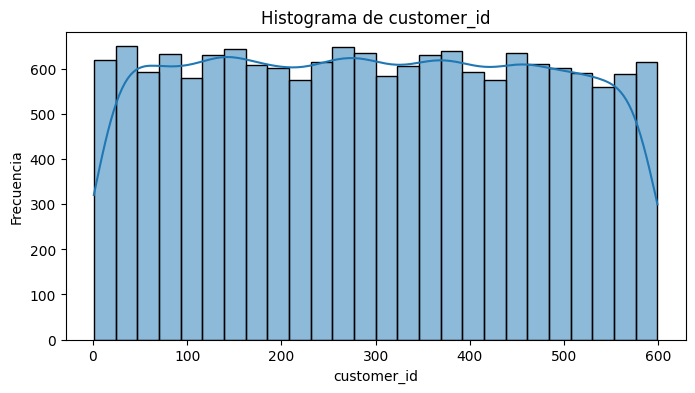

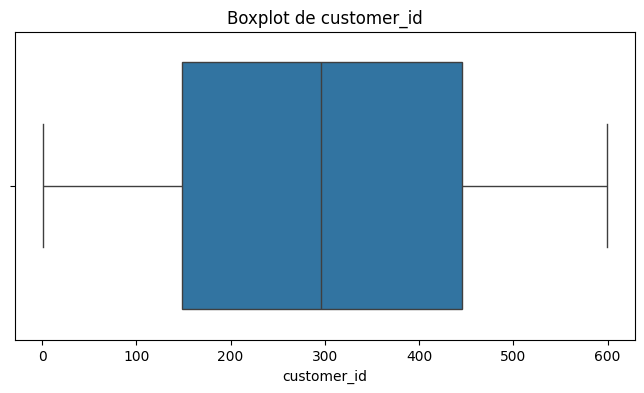

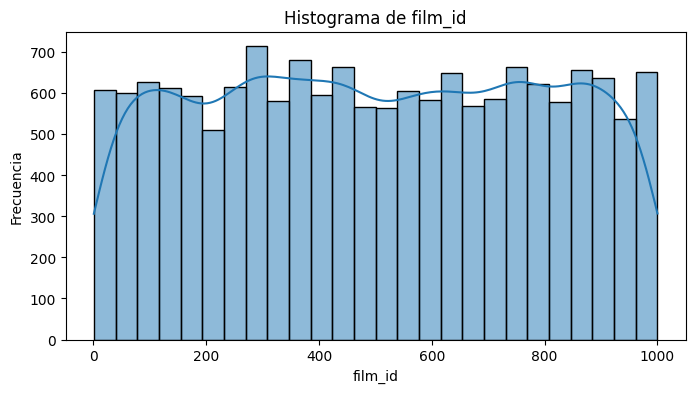

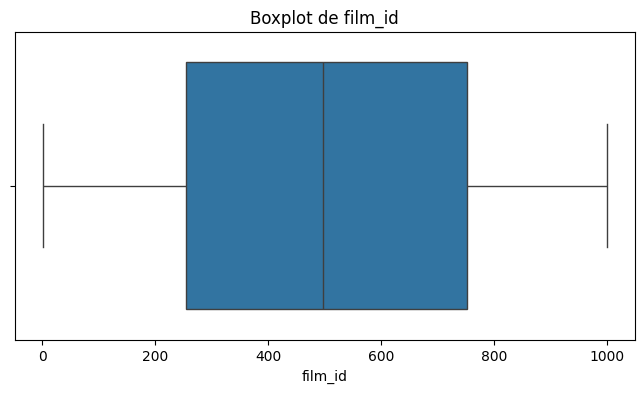

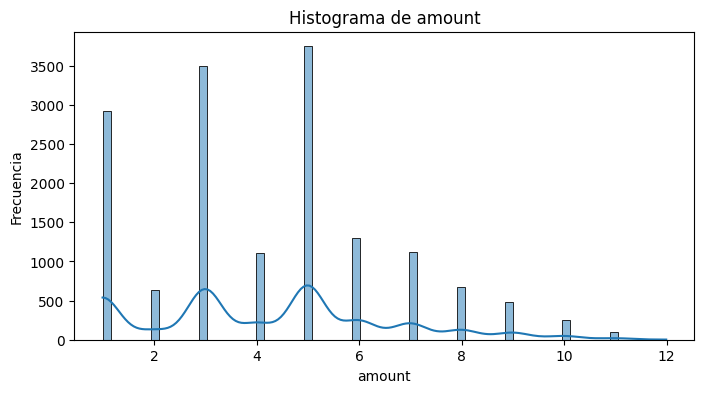

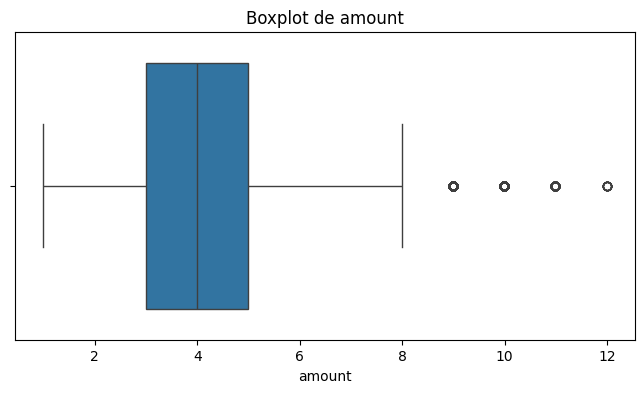

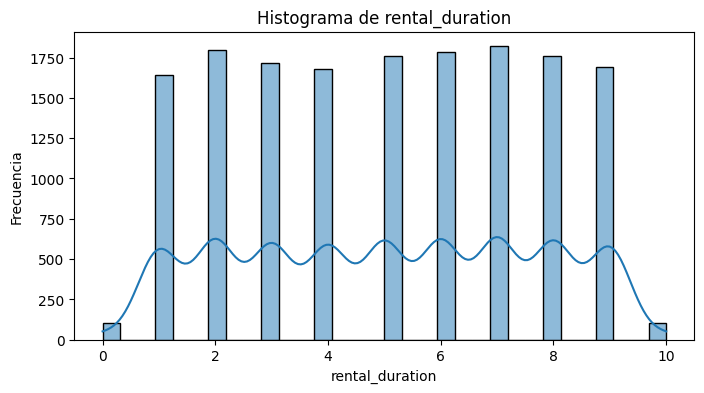

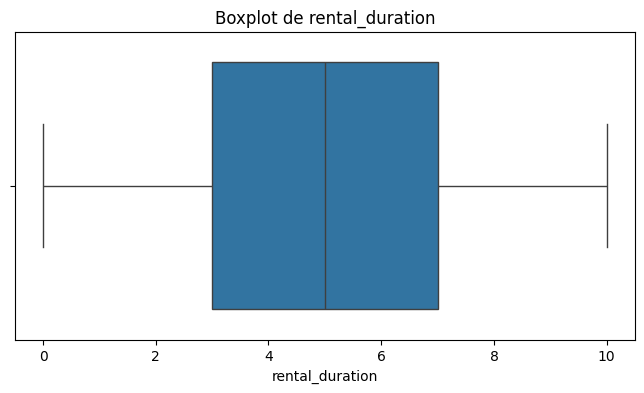

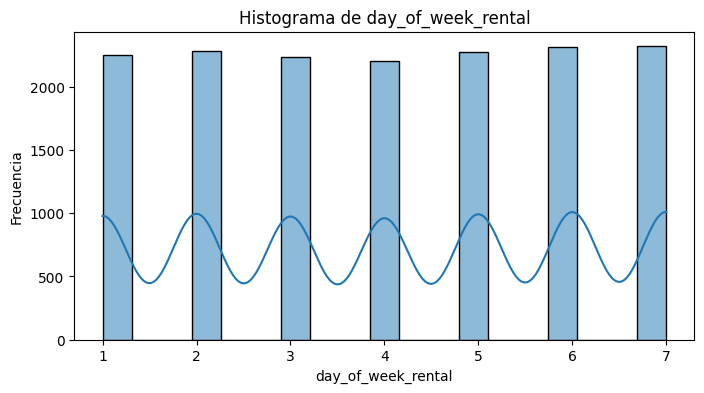

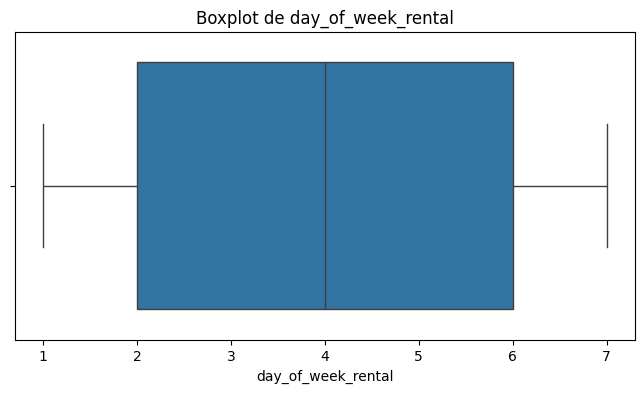

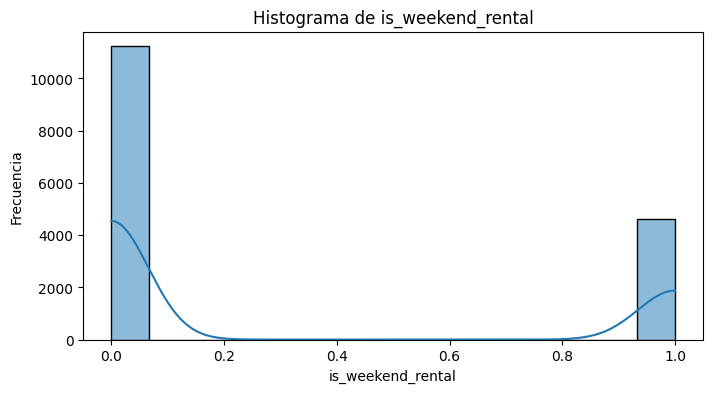

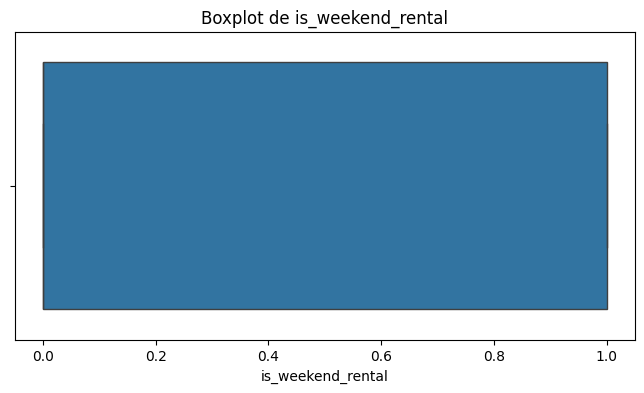

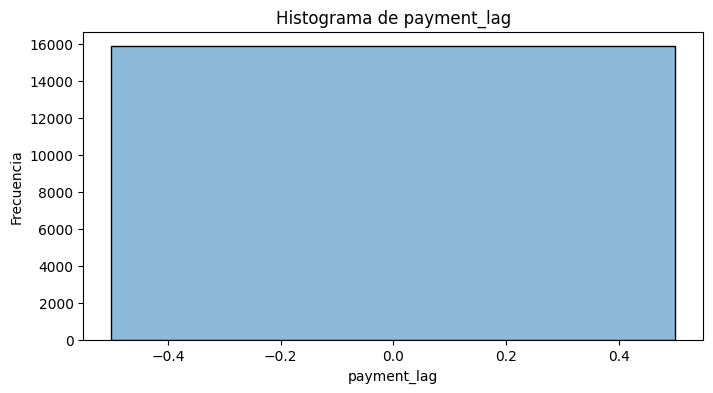

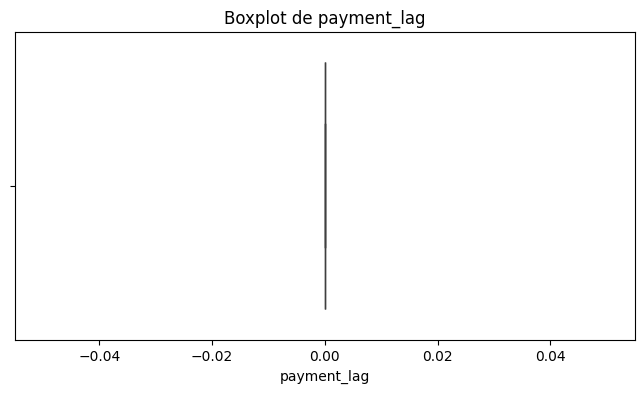

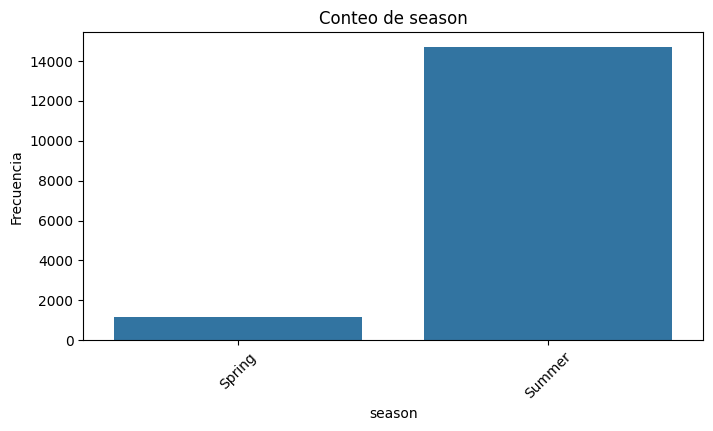

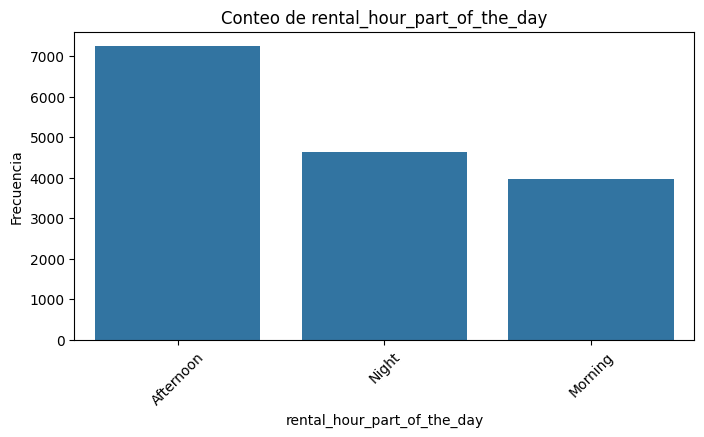

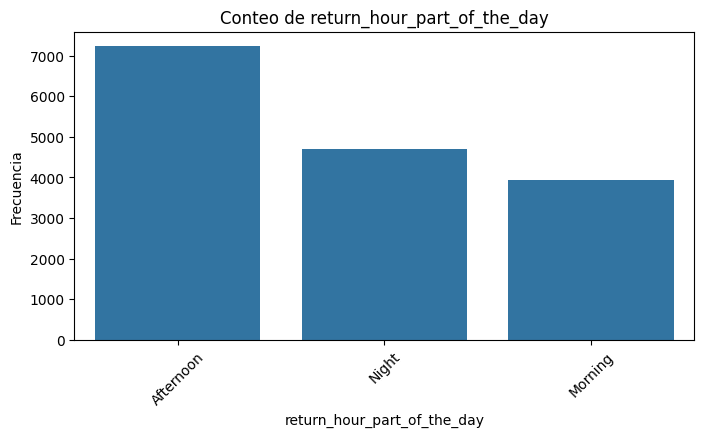

In [22]:
identify_outliers(df_clean, variables_numericas, variables_categoricas)

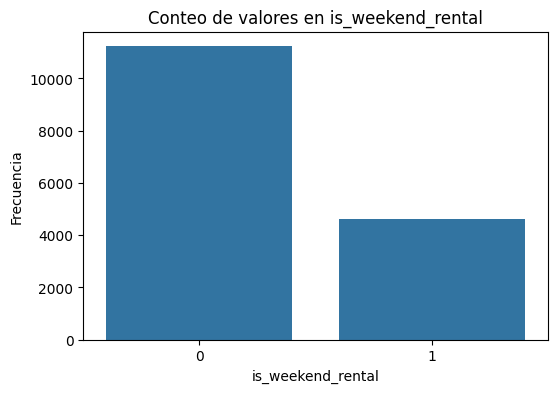

In [24]:
# Las columnas que sólo contiene valores 0-1, es mejor analizarlo con un countplot para ver la distribución de cada valor
columnas_0_1 = ['is_weekend_rental']

for col in columnas_0_1:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_clean[col])
    plt.title(f'Conteo de valores en {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

En este caso, solamente poseemos valores outliers en la columna amount, pero al tratarse de solamente 4 valores hemos decidido no realizar ningún tratamiento.

## Dashboard

### Películas más alquiladas

In [ ]:
# grafica en el dashboard
plt.figure(figsize=(20,5))
sns.countplot(x=df_clean['title'], order=df_clean['title'].value_counts().index[:10], palette='magma')
plt.title('Películas más alquiladas')
plt.show()

KeyError: 'title'

<Figure size 2000x500 with 0 Axes>

### Películas con más ingresos de alquiler

In [ ]:
# Fallo en la gráfica anterior, ya que al ordenar por el conteo de títulos, no se refleja el importe total generado por cada película. Para corregirlo, ordenamos por la suma de los importes agrupados por título.
plt.figure(figsize=(20,5))
sns.countplot(x=df_clean['title'],order=df_clean['amount'].groupby(df_clean['title']).sum().sort_values(ascending=False).index[:10], palette='magma')
plt.title('Películas más alquiladas')
plt.show()

KeyError: 'title'

<Figure size 2000x500 with 0 Axes>

### Distribución de categorías

In [27]:
plt.figure(figsize=(7,7))
plt.pie(df_clean['category'].value_counts(), labels=df_clean['category'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Gráfico de tarta distribución de categorías')
plt.show()

KeyError: 'category'

<Figure size 700x700 with 0 Axes>

### Relación Duración de alquiler y cantidad pagada

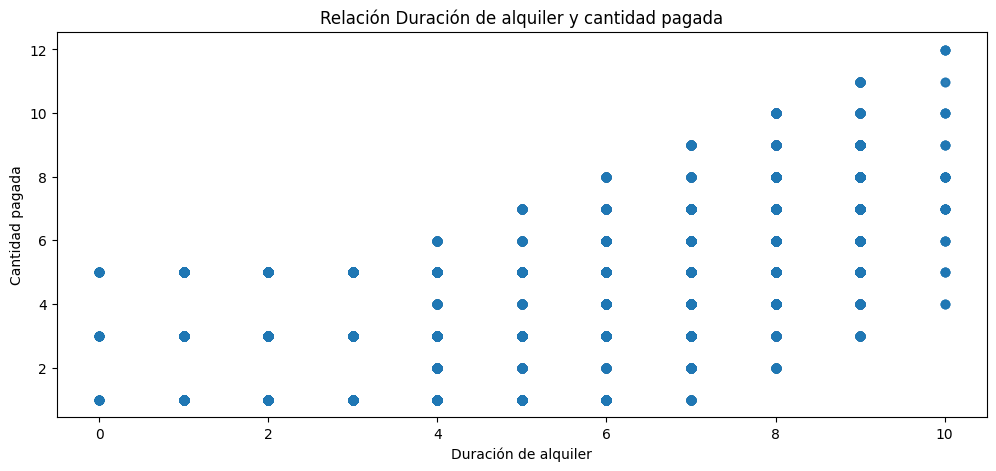

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(df_clean['rental_duration'], df_clean['amount'], alpha=0.5)
plt.title('Relación Duración de alquiler y cantidad pagada')
plt.xlabel('Duración de alquiler')
plt.ylabel('Cantidad pagada')
plt.show()

### Top 10 Países por Ingresos Totales

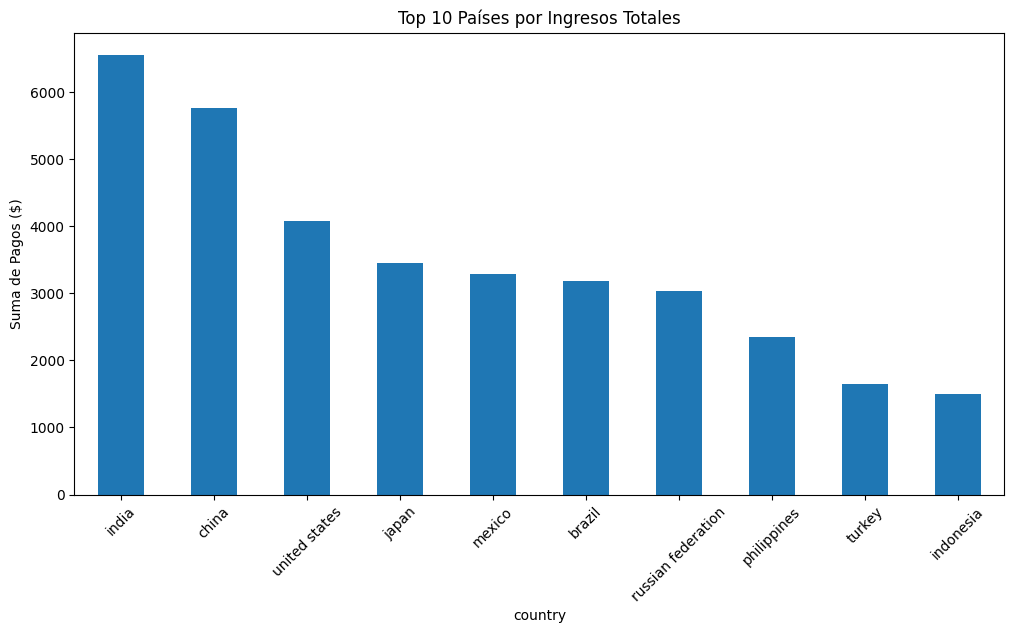

In [ ]:
top_countries = df_clean.groupby('country')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Países por Ingresos Totales')
plt.ylabel('Suma de Pagos ($)')
plt.xticks(rotation=45)
plt.show()